# Antecipação da hospitalização de casos de chikungunya utilizando aprendizado de máquina <h1>
**Autor:** Victor Coutinho Santos

**Dados:** Sistema de Informação de Agravos de Notificação (SINAN / DATASUS)

## 1. Contexto e justificativa

A chikungunya é uma arbovirose transmitida principalmente pelo mosquito *Aedes aegypti*. Embora muitos pacientes apresentem evolução favorável, alguns casos podem demandar hospitalização, especialmente quando existem condições clínicas que exigem maior acompanhamento.

Assim como no atendimento de outras arboviroses, um dos desafios é identificar quais pacientes apresentam maior possibilidade de precisar de atendimento hospitalar. Uma triagem imprecisa pode resultar em:

1. **Subestimação do caso:** liberação inadequada de um paciente que poderia necessitar de maior acompanhamento.
2. **Superestimação do caso:** encaminhamentos e utilização desnecessária de recursos hospitalares.

Dessa forma, a identificação antecipada de pacientes com maior probabilidade de hospitalização pode colaborar com a organização dos serviços de saúde.

Neste projeto, a hospitalização será utilizada como variável de interesse. É importante destacar que ela não representa exclusivamente a gravidade clínica, pois também pode ser influenciada pelo acesso e pela organização dos serviços de saúde.

# 2. Objetivo do projeto

Almeja-se o desenvolvimento de um modelo de aprendizado de máquina de **classificação binária** capaz de prever se um paciente com chikungunya será **hospitalizado ou não hospitalizado**, utilizando informações coletadas durante a notificação, como sintomas iniciais, dados demográficos e comorbidades prévias.

## 3. Sobre os dados

Os dados foram obtidos pela plataforma DATASUS e se referem aos casos de febre de chikungunya registrados no Sistema de Informação de Agravos de Notificação (SINAN) em **2024**.

O arquivo utilizado será o **CHIKBR24.csv**, obtido após a extração do arquivo compactado disponibilizado pelo Portal de Dados Abertos do SUS.

## 4. Pré-processamento dos dados

##### 4.1 Exploração, mapeamento e limpeza dos dados<h5>

Primeiro, interessa saber quais informações estão disponíveis para cada paciente. Como o arquivo pode possuir um grande volume de dados, sua leitura será realizada em blocos, seguindo a mesma estratégia utilizada no projeto original.

Para compreender o significado das colunas, será utilizado o dicionário de dados da base de febre de chikungunya disponibilizado pelo Ministério da Saúde.

As instâncias serão filtradas com base nos seguintes atributos:

- **TP_NOT:** apenas notificações individuais serão incluídas.
- **CS_SEXO:** registros com sexo ignorado serão removidos.
- **CS_GESTANT:** registros com valor ignorado serão removidos.
- **CLASSI_FIN:** serão mantidos apenas casos classificados como chikungunya.
- **CRITERIO:** serão mantidas apenas confirmações laboratoriais.
- **HOSPITALIZ:** serão mantidos somente registros que informem se houve ou não hospitalização.

A variável de interesse será **HOSPITALIZ**, transformada em uma variável binária:

- **0:** paciente não hospitalizado;
- **1:** paciente hospitalizado.

Os sintomas mantidos serão:

- febre;
- mialgia;
- cefaleia;
- exantema;
- náusea;
- dor nas costas;
- conjuntivite;
- artrite;
- artralgia;
- dor retro-orbital.

Também serão mantidas as seguintes comorbidades prévias:

- diabetes;
- doenças hematológicas;
- doenças hepáticas;
- doença renal crônica;
- hipertensão;
- doença ácido-péptica;
- doenças autoimunes.

Instâncias com algum dos atributos selecionados faltante serão removidas, seguindo o mesmo procedimento adotado no trabalho anterior.

##### 4.2 Considerações éticas e seleção de variáveis preditoras<h5>

As informações pessoalmente identificáveis são removidas dos conjuntos de dados disponibilizados pelo Ministério da Saúde.

Variáveis como raça, ocupação, município de residência e local de atendimento não serão utilizadas como preditoras, buscando evitar a introdução direta de possíveis vieses socioeconômicos ou regionais.

As variáveis preditoras serão os sintomas, as comorbidades, o sexo, a idade gestacional e a idade estimada do paciente.

##### 4.3 Engenharia de atributos e transformações<h5>

As colunas **FEM_GST** e **FEM_NAO_GST** substituirão as colunas de sexo e idade gestacional. Caso ambas sejam iguais a zero, o paciente será representado como masculino.

A idade será estimada pela subtração entre o ano da notificação e o ano de nascimento.

A presença de sintomas e comorbidades, originalmente representada pelos códigos *1 - Sim* e *2 - Não*, será convertida para *1 - Sim* e *0 - Não*.

Por fim, a variável **HOSPITALIZ** será transformada na variável-alvo:

- *2 - Não* será convertido para **0**;
- *1 - Sim* será convertido para **1**.

In [26]:
import pandas as pd
import numpy as np

# Lista de atributos selecionados
atributos = [
    'TP_NOT', 'CS_SEXO', 'CS_GESTANT', 'CLASSI_FIN', 'CRITERIO', 
    'HOSPITALIZ', 'NU_ANO', 'ANO_NASC',
    'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'NAUSEA', 'DOR_COSTAS', 
    'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA', 'DOR_RETRO', 'DIABETES', 
    'HEMATOLOG', 'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 
    'AUTO_IMUNE'
]

# Lista específica de sintomas e comorbidades para a transformação binária
sintomas_comorbidades = [
    'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'NAUSEA', 'DOR_COSTAS', 
    'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA', 'DOR_RETRO', 'DIABETES', 
    'HEMATOLOG', 'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 
    'AUTO_IMUNE'
]

blocos_processados = []

# Leitura por blocos devido às restrições de memória
bloco_iter = pd.read_csv(
    'data/csv/CHIKBR24.csv',
    sep=',',
    usecols=atributos,
    chunksize=100000,
    low_memory=False
)

print("Iniciando o processamento e filtragem dos dados...")

for i, bloco in enumerate(bloco_iter):

    # --- FILTROS DE REGISTROS ---

    # Apenas notificações individuais (código 2)
    bloco = bloco[bloco['TP_NOT'] == 2]

    # Remover sexo ignorado ou nulo
    bloco = bloco[bloco['CS_SEXO'].isin(['M', 'F'])]

    # Remover idade gestacional nula ou ignorada (9)
    bloco = bloco[
        bloco['CS_GESTANT'].notna()
        & (~bloco['CS_GESTANT'].isin([9, 9.0, '9', '9.0']))
    ]

    # Apenas casos confirmados em laboratório (código 1)
    bloco = bloco[bloco['CRITERIO'] == 1]

    # Classificação final como chikungunya (código 13)
    bloco = bloco[bloco['CLASSI_FIN'] == 13]

    # Manter apenas registros com hospitalização informada:
    # 1 = Sim e 2 = Não
    bloco = bloco[bloco['HOSPITALIZ'].isin([1, 2, 1.0, 2.0, '1', '2', '1.0', '2.0'])]

    # Remover linhas com valores faltantes nas colunas selecionadas
    bloco = bloco.dropna(subset=atributos)

    # Se o bloco ficar vazio após os filtros, não é preciso continuar
    if bloco.empty:
        continue

    # --- ENGENHARIA DE ATRIBUTOS E TRANSFORMAÇÕES ---

    # Binarização da variável-alvo:
    # 0 = Não hospitalizado e 1 = Hospitalizado
    bloco['ALVO'] = np.where(
        bloco['HOSPITALIZ'].isin([1, 1.0, '1', '1.0']),
        1,
        0
    )

    # Substituição de CS_SEXO e CS_GESTANT pelas colunas binárias
    bloco['FEM_GST'] = np.where(
        (bloco['CS_SEXO'] == 'F')
        & (
            bloco['CS_GESTANT'].isin(
                [1, 2, 3, 4, 1.0, 2.0, 3.0, 4.0, '1', '2', '3', '4']
            )
        ),
        1,
        0
    )

    bloco['FEM_NAO_GST'] = np.where(
        (bloco['CS_SEXO'] == 'F')
        & (
            bloco['CS_GESTANT'].isin(
                [5, 6, 5.0, 6.0, '5', '6']
            )
        ),
        1,
        0
    )

    # Cálculo da idade
    bloco['IDADE'] = (
        bloco['NU_ANO'].astype(int)
        - bloco['ANO_NASC'].astype(int)
    )

    # Conversão de sintomas e comorbidades para 0 e 1
    for col in sintomas_comorbidades:
        bloco[col] = np.where(bloco[col] == 1, 1, 0)

    # Remoção das colunas usadas apenas nos filtros ou transformações
    colunas_descarte = [
        'TP_NOT', 'CS_SEXO', 'CS_GESTANT', 'CLASSI_FIN',
        'CRITERIO', 'HOSPITALIZ', 'NU_ANO', 'ANO_NASC'
    ]

    bloco_final = bloco.drop(columns=colunas_descarte)
    blocos_processados.append(bloco_final)

# Concatenação e salvamento do arquivo processado
if blocos_processados:
    chikbr24_limpo = pd.concat(blocos_processados, ignore_index=True)

    chikbr24_limpo.to_csv('data/csv/CHIKBR24_processado.csv', index=False)

    print("\n--- Processamento concluído com sucesso! ---")
    print(f"Total de instâncias salvas: {len(chikbr24_limpo)}")
    print("\nEstrutura final das variáveis:")
    print(chikbr24_limpo.info())
else:
    print("Nenhum registro correspondeu aos filtros aplicados.")

Iniciando o processamento e filtragem dos dados...

--- Processamento concluído com sucesso! ---
Total de instâncias salvas: 68488

Estrutura final das variáveis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68488 entries, 0 to 68487
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   FEBRE        68488 non-null  int64
 1   MIALGIA      68488 non-null  int64
 2   CEFALEIA     68488 non-null  int64
 3   EXANTEMA     68488 non-null  int64
 4   NAUSEA       68488 non-null  int64
 5   DOR_COSTAS   68488 non-null  int64
 6   CONJUNTVIT   68488 non-null  int64
 7   ARTRITE      68488 non-null  int64
 8   ARTRALGIA    68488 non-null  int64
 9   DOR_RETRO    68488 non-null  int64
 10  DIABETES     68488 non-null  int64
 11  HEMATOLOG    68488 non-null  int64
 12  HEPATOPAT    68488 non-null  int64
 13  RENAL        68488 non-null  int64
 14  HIPERTENSA   68488 non-null  int64
 15  ACIDO_PEPT   68488 non-null  int64
 16  AUT

Dos atributos iniciais, apenas as variáveis selecionadas, modificadas e engenheiradas seguirão para o treinamento dos algoritmos de aprendizado de máquina.

##### 4.4 Balanceamento

Após as filtragens, é importante analisar o balanceamento entre os pacientes não hospitalizados e hospitalizados.

In [2]:
import pandas as pd
import numpy as np

# Carregar o arquivo final processado
chikungunya_final = pd.read_csv('CHIKBR24_processado.csv')

# Calcular a contagem absoluta e percentual da variável-alvo
print(chikungunya_final['ALVO'].value_counts(normalize=True))
print(chikungunya_final['ALVO'].value_counts())

ALVO
0    0.961117
1    0.038883
Name: proportion, dtype: float64
ALVO
0    65825
1     2663
Name: count, dtype: int64


É esperado que exista um desbalanceamento entre as classes, com uma quantidade menor de pacientes hospitalizados.

Caso isso não fosse considerado durante o treinamento, o algoritmo poderia priorizar a classe majoritária e apresentar uma acurácia elevada sem detectar adequadamente os pacientes hospitalizados.

As mesmas abordagens consideradas no projeto original continuam possíveis:

- Sobreamostragem;
- Subamostragem;
- **Pesos atribuídos às classes**.

Neste projeto, usaremos a estratégia de utilização de **pesos**, sem criar ou remover registros do conjunto de dados.

## 5. Treinamento do algoritmo

##### 5.1 Seleção de algoritmos<h5>

Serão utilizados os mesmos quatro algoritmos:

- regressão logística;
- árvore de decisão;
- floresta aleatória;
- XGBoost.

A escolha considera que o problema é de classificação, que existe desbalanceamento entre as classes, que há limitações de hardware e que se deseja analisar a importância das variáveis.

##### 5.2 Divisão dos conjuntos de teste e treino<h5>

Os conjuntos de treino e teste serão separados na proporção de 70% e 30%, respectivamente.

A divisão será estratificada para preservar a proporção de pacientes hospitalizados e não hospitalizados nos dois conjuntos.

Como apenas a variável **IDADE** não varia entre 0 e 1, ela será normalizada somente para a regressão logística, seguindo o mesmo procedimento utilizado no projeto anterior.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Separar variáveis preditoras (x) e variável-alvo (y)
x = chikungunya_final.drop(columns=['ALVO'])
y = chikungunya_final['ALVO']

# Dividir em treino e teste (70/30) com estratificação
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    stratify=y,
    random_state=15
)

# Criar o transformador que escala os dados entre 0 e 1
scaler = MinMaxScaler()

# Ajustar o transformador na idade do treino
x_train_lr = x_train.copy()
x_train_lr['IDADE'] = scaler.fit_transform(x_train[['IDADE']])

# Aplicar a mesma transformação na idade do teste
x_test_lr = x_test.copy()
x_test_lr['IDADE'] = scaler.transform(x_test[['IDADE']])

In [4]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import matplotlib.pyplot as plt


def avaliar_modelo(y_real, y_predito, nome_modelo):
    
    # Calcular as métricas
    acuracia = accuracy_score(y_real, y_predito)
    precisao = precision_score(
        y_real,
        y_predito,
        pos_label=1,
        zero_division=0
    )
    recall = recall_score(
        y_real,
        y_predito,
        pos_label=1,
        zero_division=0
    )
    f1 = f1_score(
        y_real,
        y_predito,
        pos_label=1,
        zero_division=0
    )
    
    print("\n" + "=" * 55)
    print(f"RESULTADOS — {nome_modelo.upper()}")
    print("=" * 55)
    
    print(f"Acurácia: {acuracia * 100:.2f}%")
    print(f"Precisão: {precisao * 100:.2f}%")
    print(f"Recall:   {recall * 100:.2f}%")
    print(f"F1-score: {f1 * 100:.2f}%")
    
    print("\nRelatório de classificação:")
    
    print(
        classification_report(
            y_real,
            y_predito,
            target_names=[
                "Não hospitalizado",
                "Hospitalizado"
            ],
            digits=4,
            zero_division=0
        )
    )
    
    # Matriz de confusão
    ConfusionMatrixDisplay.from_predictions(
        y_real,
        y_predito,
        display_labels=[
            "Não hospitalizado",
            "Hospitalizado"
        ],
        values_format="d"
    )
    
    plt.title(f"Matriz de confusão — {nome_modelo}")
    plt.tight_layout()
    plt.show()

##### 5.3 Regressão logística<h5>

O primeiro algoritmo será a regressão logística. Será utilizado um *solver* que permita testar penalidades L1 e L2.

O número máximo de iterações será mantido em 1000, e o `random_state` continuará com valor 15 para possibilitar a reprodução do experimento.

In [19]:
from sklearn.linear_model import LogisticRegression

# Criar o modelo base (usando um solver quer permita penalidades L1 e L2)
lr_base = LogisticRegression(solver='liblinear', max_iter=1000, random_state=15, verbose=1)

O *RandomizedSearchCV* será utilizado para testar combinações aleatórias de hiperparâmetros.

A validação cruzada será realizada com cinco divisões, e a melhor combinação será escolhida com base na **sensibilidade (recall)**.

Nesse contexto, a premissa é que deixar de identificar um paciente que será hospitalizado pode ser mais prejudicial do que encaminhar para maior atenção um paciente que não será hospitalizado.

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_score, recall_score

# Definir o espaço de busca
espaco_parametros = {
    'penalty': ['l1', 'l2'], #Penalidades
    'C': [0.01, 0.05, 0.1, 0.5], #Quanto o modelo deve se importar com os erros
    'class_weight': [{0: 1, 1: 16}, {0: 1, 1: 32}] # Pesos atribuídos à classe dos pacientes hospitalizados.
}

# Configurar a busca aleatória
# scoring='recall' escolhe a combinação que melhor detecta pacientes hospitalizados
busca_aleatoria = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=espaco_parametros,
    n_iter=10, #Sortear 10 combinações
    scoring='recall', 
    cv=5, #Divisão dos dados em 5 para validação cruzada           
    random_state=15,
    verbose=2       
)

busca_aleatoria.fit(x_train_lr, y_train)

# Pegar o melhor modelo e fazer as predições na base de teste
melhor_modelo = busca_aleatoria.best_estimator_
y_pred_melhor = melhor_modelo.predict(x_test_lr)

# Calcular as métricas específicas para a classe 1 (pacientes hospitalizados)
# pos_label=1 para medir o desempenho da classe de interesse
precisao_grave = precision_score(y_test, y_pred_melhor, pos_label=1)
sensibilidade_grave = recall_score(y_test, y_pred_melhor, pos_label=1)

print("\n" + "="*50)
print("             RESULTADOS FINAIS DO MODELO         ")
print("="*50)

# Exibe a melhor combinação encontrada
print("🏆 MELHOR COMBINAÇÃO DE PARAMETROS ENCONTRADA:")
for param, valor in busca_aleatoria.best_params_.items():
    print(f" > {param}: {valor}")

print("\n📈 MÉTRICAS DO MELHOR MODELO (CLASSE 1 - HOSPITALIZADOS):")
print(f" > Precisão:     {precisao_grave * 100:.2f}%")
print(f" > Sensibilidade: {sensibilidade_grave * 100:.2f}%")
print("="*50)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LibLinear][CV] END .....C=0.05, class_weight={0: 1, 1: 16}, penalty=l1; total time=   0.0s
[LibLinear]

c:\Users\victo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\victo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\victo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default va

[CV] END .....C=0.05, class_weight={0: 1, 1: 16}, penalty=l1; total time=   0.0s
[LibLinear][CV] END .....C=0.05, class_weight={0: 1, 1: 16}, penalty=l1; total time=   0.0s
[LibLinear]

c:\Users\victo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\victo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\victo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default va

[CV] END .....C=0.05, class_weight={0: 1, 1: 16}, penalty=l1; total time=   0.0s
[LibLinear][CV] END .....C=0.05, class_weight={0: 1, 1: 16}, penalty=l1; total time=   0.0s
[LibLinear][CV] END ......C=0.1, class_weight={0: 1, 1: 16}, penalty=l2; total time=   0.0s


...

[LibLinear][CV] END ......C=0.1, class_weight={0: 1, 1: 32}, penalty=l2; total time=   0.0s
[LibLinear]

c:\Users\victo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\victo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END ......C=0.1, class_weight={0: 1, 1: 32}, penalty=l2; total time=   0.0s
[LibLinear][CV] END ......C=0.1, class_weight={0: 1, 1: 32}, penalty=l2; total time=   0.0s
[LibLinear][CV] END ......C=0.1, class_weight={0: 1, 1: 32}, penalty=l2; total time=   0.0s
[LibLinear]

c:\Users\victo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\victo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(



             RESULTADOS FINAIS DO MODELO         
🏆 MELHOR COMBINAÇÃO DE PARAMETROS ENCONTRADA:
 > penalty: l1
 > class_weight: {0: 1, 1: 32}
 > C: 0.01

📈 MÉTRICAS DO MELHOR MODELO (CLASSE 1 - HOSPITALIZADOS):
 > Precisão:     5.73%
 > Sensibilidade: 75.34%


*Matriz de confusão*


RESULTADOS — REGRESSÃO LOGÍSTICA
Acurácia: 50.80%
Precisão: 5.73%
Recall:   75.34%
F1-score: 10.64%

Relatório de classificação:
                   precision    recall  f1-score   support

Não hospitalizado     0.9804    0.4980    0.6605     19748
    Hospitalizado     0.0573    0.7534    0.1064       799

         accuracy                         0.5080     20547
        macro avg     0.5188    0.6257    0.3835     20547
     weighted avg     0.9445    0.5080    0.6390     20547



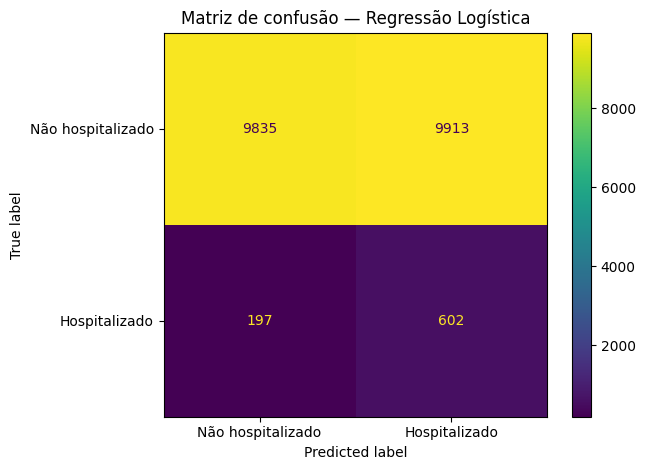

In [21]:
avaliar_modelo(
    y_test,
    y_pred_melhor,
    "Regressão Logística"
)

A célula acima apresentará a melhor combinação de hiperparâmetros encontrada, juntamente com a precisão e a sensibilidade para a classe dos pacientes hospitalizados.

Com vistas à explicabilidade, será analisada a influência das variáveis preditoras no resultado final.

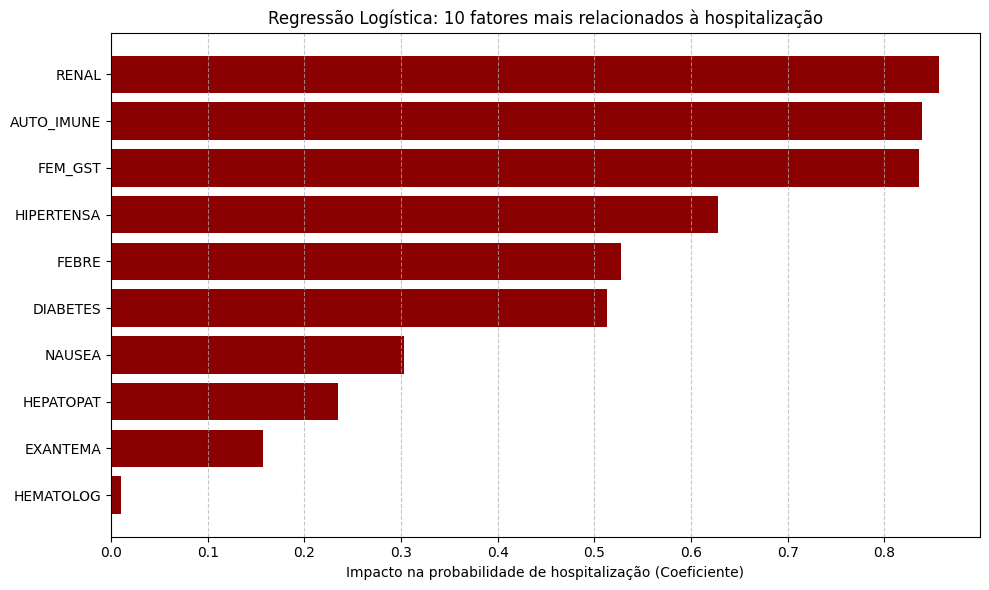

Pesos matemáticos de cada variável na Regressão Logística:
   Variável  Coeficiente (peso)
      RENAL            0.856115
 AUTO_IMUNE            0.839323
    FEM_GST            0.835598
 HIPERTENSA            0.627573
      FEBRE            0.527745
   DIABETES            0.513384
     NAUSEA            0.302799
  HEPATOPAT            0.234321
   EXANTEMA            0.157141
  HEMATOLOG            0.009871
 ACIDO_PEPT            0.000000
 CONJUNTVIT           -0.085137
  ARTRALGIA           -0.213336
FEM_NAO_GST           -0.235136
    MIALGIA           -0.256885
  DOR_RETRO           -0.341918
    ARTRITE           -0.396142
 DOR_COSTAS           -0.477954
   CEFALEIA           -0.580179
      IDADE           -0.711372


In [22]:
import matplotlib.pyplot as plt

# Pegar os coeficientes do melhor modelo treinado
coeficientes = melhor_modelo.coef_[0]
nomes_atributos = x_train.columns

# Criar um dataframe para organizar os pesos
df_importancia_lr = pd.DataFrame({
    'Variável': nomes_atributos,
    'Coeficiente (peso)': coeficientes
})

# Ordenar do impacto mais grave para o menor
df_importancia_lr = df_importancia_lr.sort_values(by='Coeficiente (peso)', ascending=False)

# Plotar o gráfico de impacto
plt.figure(figsize=(10, 6))
plt.barh(df_importancia_lr['Variável'].head(10)[::-1], df_importancia_lr['Coeficiente (peso)'].head(10)[::-1], color='darkred')
plt.xlabel('Impacto na probabilidade de hospitalização (Coeficiente)')
plt.title('Regressão Logística: 10 fatores mais relacionados à hospitalização')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Mostrar a tabela
print("Pesos matemáticos de cada variável na Regressão Logística:")
print(df_importancia_lr.to_string(index=False))

##### 5.4 Árvore de decisão<h5>

A mesma abordagem será adotada para a criação da árvore de decisão, variando-se hiperparâmetros e escolhendo combinações de forma aleatória.

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Criar o modelo base
dt_base = DecisionTreeClassifier(random_state=15)

# Definir o espaço de busca 
espaco_parametros_dt = {
    'criterion': ['gini', 'entropy'], #Critérios para fazer os cortes (separar os nós)
    'max_depth': [4, 5, 6, 7, 8], #Pensando na explicabilidade, quanto mais profundo, mais complexa
    'class_weight': [{0: 1, 1: 16}, {0: 1, 1: 32}]
}

# Configurar e rodar a busca aleatória
busca_aleatoria_ad = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=espaco_parametros_dt,
    n_iter=10, 
    scoring='recall', 
    cv=5,            
    random_state=15,
    verbose=2        
)

busca_aleatoria_ad.fit(x_train, y_train)

# Pegar o melhor modelo e fazer as predições na base de teste
melhor_dt = busca_aleatoria_ad.best_estimator_
y_pred_dt = melhor_dt.predict(x_test)

# Calcular as métricas específicas para a classe 1 (Hospitalizados)
precisao_dt = precision_score(y_test, y_pred_dt, pos_label=1)
sensibilidade_dt = recall_score(y_test, y_pred_dt, pos_label=1)

print("\n" + "="*50)
print("         RESULTADOS FINAIS - ÁRVORE DE DECISÃO     ")
print("="*50)

# Exibe a melhor combinação encontrada
print("🏆 MELHOR COMBINAÇÃO DE PARAMETROS ENCONTRADA:")
for param, valor in busca_aleatoria_ad.best_params_.items():
    print(f" • {param}: {valor}")

print("\n📈 MÉTRICAS DO MELHOR MODELO (CLASSE 1 - HOSPITALIZADOS):")
print(f" • Precisão:     {precisao_dt * 100:.2f}%")
print(f" • Sensibilidade: {sensibilidade_dt * 100:.2f}%")
print("="*50)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END class_weight={0: 1, 1: 32}, criterion=entropy, max_depth=8; total time=   0.0s
[CV] END class_weight={0: 1, 1: 32}, criterion=entropy, max_depth=8; total time=   0.0s
[CV] END class_weight={0: 1, 1: 32}, criterion=entropy, max_depth=8; total time=   0.0s
[CV] END class_weight={0: 1, 1: 32}, criterion=entropy, max_depth=8; total time=   0.0s
[CV] END class_weight={0: 1, 1: 32}, criterion=entropy, max_depth=8; total time=   0.0s
[CV] END class_weight={0: 1, 1: 32}, criterion=entropy, max_depth=4; total time=   0.0s
[CV] END class_weight={0: 1, 1: 32}, criterion=entropy, max_depth=4; total time=   0.0s
[CV] END class_weight={0: 1, 1: 32}, criterion=entropy, max_depth=4; total time=   0.0s
[CV] END class_weight={0: 1, 1: 32}, criterion=entropy, max_depth=4; total time=   0.0s
[CV] END class_weight={0: 1, 1: 32}, criterion=entropy, max_depth=4; total time=   0.0s
[CV] END class_weight={0: 1, 1: 16}, criterion=gini, max_de


RESULTADOS — ÁRVORE DE DECISÃO
Acurácia: 37.05%
Precisão: 4.90%
Recall:   82.60%
F1-score: 9.26%

Relatório de classificação:
                   precision    recall  f1-score   support

Não hospitalizado     0.9804    0.3520    0.5181     19748
    Hospitalizado     0.0490    0.8260    0.0926       799

         accuracy                         0.3705     20547
        macro avg     0.5147    0.5890    0.3053     20547
     weighted avg     0.9442    0.3705    0.5015     20547



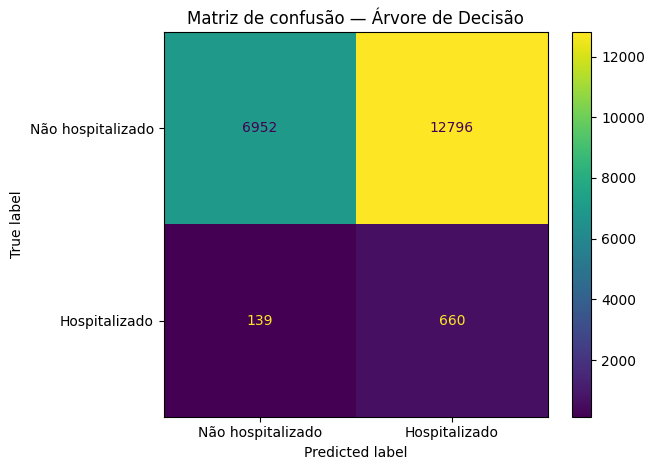

In [10]:
avaliar_modelo(
    y_test,
    y_pred_dt,
    "Árvore de Decisão"
)

A célula acima apresentará a melhor combinação de hiperparâmetros, a precisão e a sensibilidade da árvore de decisão.

Ao desenhar a árvore, será possível visualizar um fluxograma das principais decisões realizadas pelo modelo.

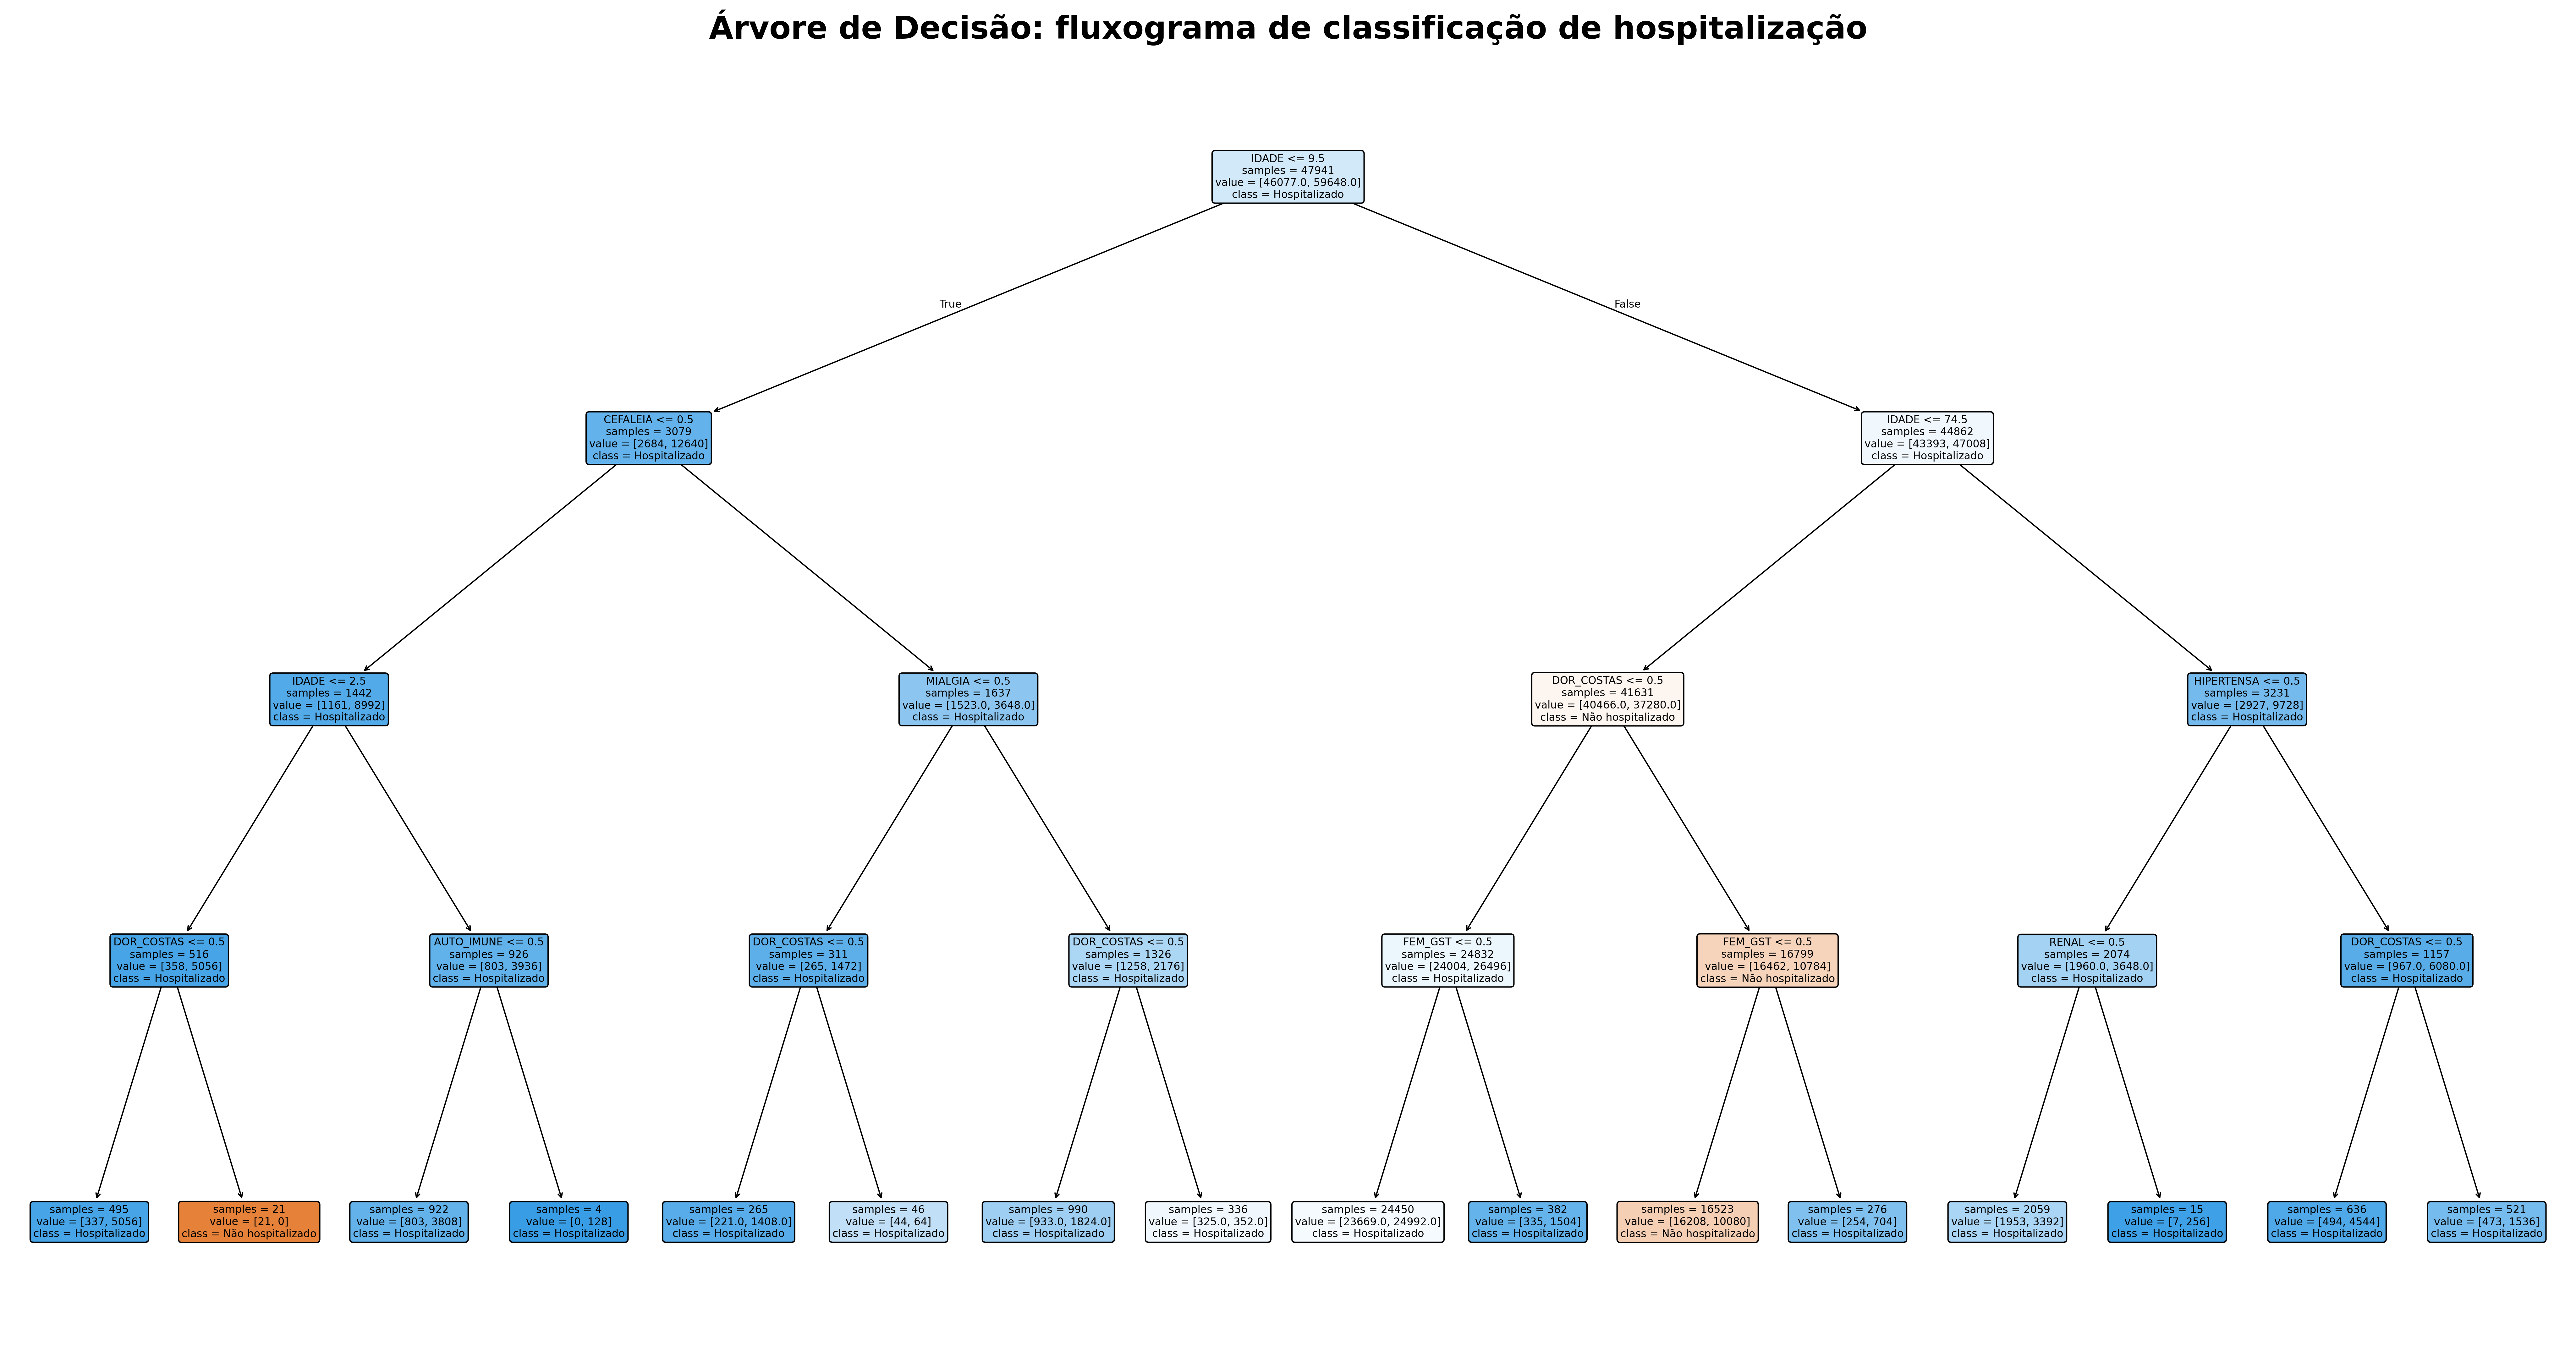

In [27]:
from sklearn.tree import plot_tree

# Criar uma figura grande com alta resolução
fig, ax = plt.subplots(figsize=(35, 18), dpi=300)

# Plotar os primeiros três níveis para manter o resultado legível
plot_tree(
    melhor_dt, 
    max_depth=4,                    
    feature_names=list(x_train.columns), 
    class_names=['Não hospitalizado', 'Hospitalizado'], 
    filled=True, 
    rounded=True, 
    fontsize=8,                  
    precision=2,                    # Limita as casas decimais dos cálculos
    impurity=False,                 # Remove o valor do gini/entropy para limpar texto
    ax=ax
)

plt.title("Árvore de Decisão: fluxograma de classificação de hospitalização", fontsize=24, weight='bold')

# Salva uma imagem no computador
plt.savefig('figuras/arvore_decisao_chikungunya.png', bbox_inches='tight', dpi=300)
plt.show()

##### 5.5 Floresta aleatória<h5>

Agora, a mesma abordagem será aplicada à floresta aleatória.

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Criar o modelo base
# n_jobs=-1 para o algoritmo usar todos os núcleos do processador e ser mais rápido
rf_base = RandomForestClassifier(n_jobs=-1, random_state=15)

# Definir o espaço de busca
espaco_parametros_rf = {
    'n_estimators': [20, 30],            # Número de árvores
    'max_depth': [5, 6],                 # Árvores curtas para não estourar a memória
    'criterion': ['gini', 'entropy'],
    'class_weight': [{0: 1, 1: 16}, {0: 1, 1: 32}]
}

# Configurar e rodar a busca aleatória
busca_randomica_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=espaco_parametros_rf,
    n_iter=10, 
    scoring='recall', 
    cv=5,            
    random_state=15,
    verbose=2        
)

busca_randomica_rf.fit(x_train, y_train)

# Pegar o melhor modelo e fazer as predições na base de teste
melhor_rf = busca_randomica_rf.best_estimator_
y_pred_rf = melhor_rf.predict(x_test)

# Calcular as métricas específicas para a classe 1
precisao_rf = precision_score(y_test, y_pred_rf, pos_label=1)
sensibilidade_rf = recall_score(y_test, y_pred_rf, pos_label=1)

print("\n" + "="*50)
print("         RESULTADOS FINAIS - RANDOM FOREST        ")
print("="*50)

# Exibe a melhor combinação encontrada
print("🏆 MELHOR COMBINAÇÃO DE PARAMETROS ENCONTRADA:")
for param, valor in busca_randomica_rf.best_params_.items():
    print(f" • {param}: {valor}")

print("\n📈 MÉTRICAS DO MELHOR MODELO (CLASSE 1 - HOSPITALIZADOS):")
print(f" • Precisão:     {precisao_rf * 100:.2f}%")
print(f" • Sensibilidade: {sensibilidade_rf * 100:.2f}%")
print("="*50)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END class_weight={0: 1, 1: 16}, criterion=entropy, max_depth=5, n_estimators=20; total time=   0.0s
[CV] END class_weight={0: 1, 1: 16}, criterion=entropy, max_depth=5, n_estimators=20; total time=   0.0s
[CV] END class_weight={0: 1, 1: 16}, criterion=entropy, max_depth=5, n_estimators=20; total time=   0.0s
[CV] END class_weight={0: 1, 1: 16}, criterion=entropy, max_depth=5, n_estimators=20; total time=   0.1s
[CV] END class_weight={0: 1, 1: 16}, criterion=entropy, max_depth=5, n_estimators=20; total time=   0.0s
[CV] END class_weight={0: 1, 1: 32}, criterion=gini, max_depth=5, n_estimators=30; total time=   0.1s
[CV] END class_weight={0: 1, 1: 32}, criterion=gini, max_depth=5, n_estimators=30; total time=   0.1s
[CV] END class_weight={0: 1, 1: 32}, criterion=gini, max_depth=5, n_estimators=30; total time=   0.1s
[CV] END class_weight={0: 1, 1: 32}, criterion=gini, max_depth=5, n_estimators=30; total time=   0.1s
[CV] E

A célula acima apresentará a melhor combinação de hiperparâmetros, a precisão e a sensibilidade da floresta aleatória.

A relevância das variáveis será analisada pela importância calculada pelo próprio modelo.


RESULTADOS — RANDOM FOREST
Acurácia: 55.03%
Precisão: 6.22%
Recall:   75.09%
F1-score: 11.50%

Relatório de classificação:
                   precision    recall  f1-score   support

Não hospitalizado     0.9818    0.5422    0.6986     19748
    Hospitalizado     0.0622    0.7509    0.1150       799

         accuracy                         0.5503     20547
        macro avg     0.5220    0.6466    0.4068     20547
     weighted avg     0.9460    0.5503    0.6759     20547



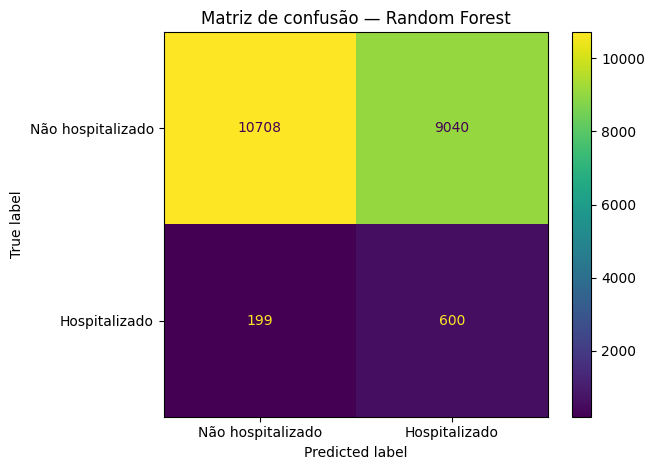

In [13]:
avaliar_modelo(
    y_test,
    y_pred_rf,
    "Random Forest"
)

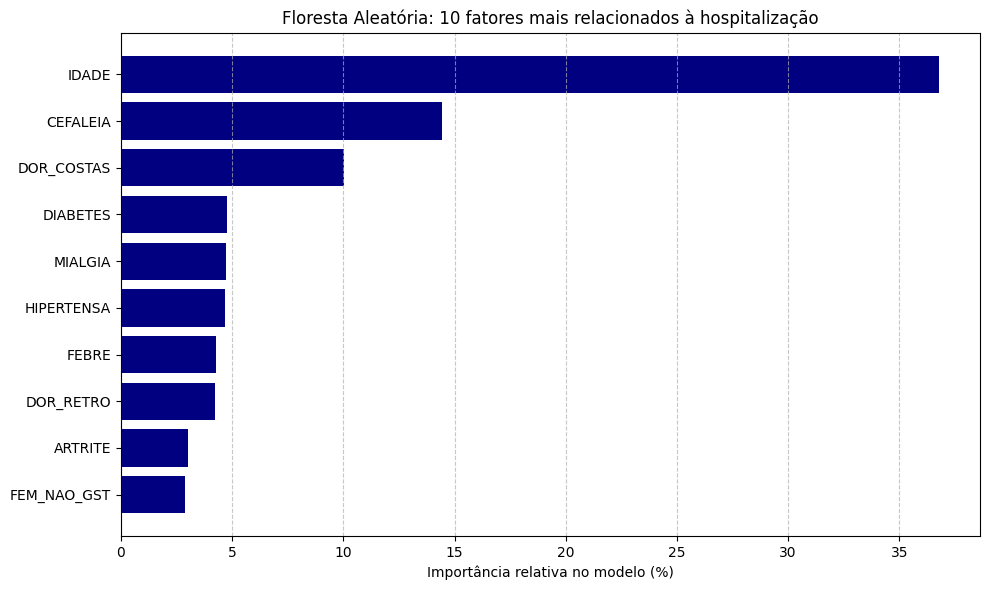

Importância das variáveis na Floresta Aleatória:
   Variável  Importância (%)
      IDADE        36.788492
   CEFALEIA        14.443884
 DOR_COSTAS        10.008751
   DIABETES         4.758649
    MIALGIA         4.729288
 HIPERTENSA         4.668822
      FEBRE         4.275592
  DOR_RETRO         4.230352
    ARTRITE         3.027836
FEM_NAO_GST         2.865512
    FEM_GST         2.805798
  ARTRALGIA         2.288440
      RENAL         1.627580
   EXANTEMA         1.024373
     NAUSEA         0.854373
 AUTO_IMUNE         0.561627
  HEPATOPAT         0.374344
  HEMATOLOG         0.350651
 CONJUNTVIT         0.237984
 ACIDO_PEPT         0.077650


In [14]:
importancias = melhor_rf.feature_importances_
nomes_atributos = x_train.columns

# Criar dataframe organizador
df_importancia_rf = pd.DataFrame({
    'Variável': nomes_atributos,
    'Importância (%)': importancias * 100
}).sort_values(by='Importância (%)', ascending=False)

# Plotar o gráfico
plt.figure(figsize=(10, 6))
plt.barh(df_importancia_rf['Variável'].head(10)[::-1], df_importancia_rf['Importância (%)'].head(10)[::-1], color='navy')
plt.xlabel('Importância relativa no modelo (%)')
plt.title('Floresta Aleatória: 10 fatores mais relacionados à hospitalização')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Importância das variáveis na Floresta Aleatória:")
print(df_importancia_rf.to_string(index=False))

##### 5.6 XGBoost<h5>

Por fim, a mesma abordagem será aplicada ao XGBoost.

In [15]:
from xgboost import XGBClassifier

# Criar o modelo base
# n_jobs=-1 para usar todos os núcleos disponíveis
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=15,
    n_jobs=-1
)

# Definir o espaço de busca
# scale_pos_weight funciona como o "peso" da classe minoritária no XGBoost
espaco_parametros_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [16,32]
}

# Configurar e rodar a busca aleatória
busca_randomica_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=espaco_parametros_xgb,
    n_iter=10,
    scoring='recall',
    cv=5,
    random_state=15,
    verbose=2
)

busca_randomica_xgb.fit(x_train, y_train)

# Pegar o melhor modelo e fazer as predições na base de teste
melhor_xgb = busca_randomica_xgb.best_estimator_
y_pred_xgb = melhor_xgb.predict(x_test)

# Calcular as métricas específicas para a classe 1
precisao_xgb = precision_score(y_test, y_pred_xgb, pos_label=1)
sensibilidade_xgb = recall_score(y_test, y_pred_xgb, pos_label=1)

print("\n" + "="*50)
print("             RESULTADOS FINAIS - XGBOOST          ")
print("="*50)

print("🏆 MELHOR COMBINAÇÃO DE PARAMETROS ENCONTRADA:")
for param, valor in busca_randomica_xgb.best_params_.items():
    print(f" • {param}: {valor}")

print("\n📈 MÉTRICAS DO MELHOR MODELO (CLASSE 1 - HOSPITALIZADOS):")
print(f" • Precisão:       {precisao_xgb * 100:.2f}%")
print(f" • Sensibilidade:  {sensibilidade_xgb * 100:.2f}%")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=100, scale_pos_weight=32, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=100, scale_pos_weight=32, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=100, scale_pos_weight=32, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=100, scale_pos_weight=32, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=100, scale_pos_weight=32, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, n_estimators=50, scale_pos_weight=16, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, n_estimators=50, scale_pos_weight=16, subsample=1.0; total 


RESULTADOS — XGBOOST
Acurácia: 26.52%
Precisão: 4.62%
Recall:   90.99%
F1-score: 8.78%

Relatório de classificação:
                   precision    recall  f1-score   support

Não hospitalizado     0.9850    0.2392    0.3849     19748
    Hospitalizado     0.0462    0.9099    0.0878       799

         accuracy                         0.2652     20547
        macro avg     0.5156    0.5745    0.2364     20547
     weighted avg     0.9485    0.2652    0.3733     20547



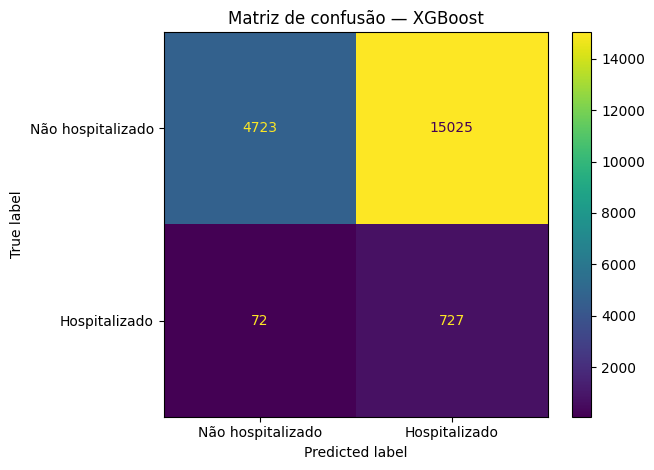

In [16]:
avaliar_modelo(
    y_test,
    y_pred_xgb,
    "XGBoost"
)

A célula acima apresentará a melhor combinação de hiperparâmetros, a precisão e a sensibilidade do XGBoost.

Assim como na floresta aleatória, será analisada a importância das variáveis utilizadas pelo modelo.

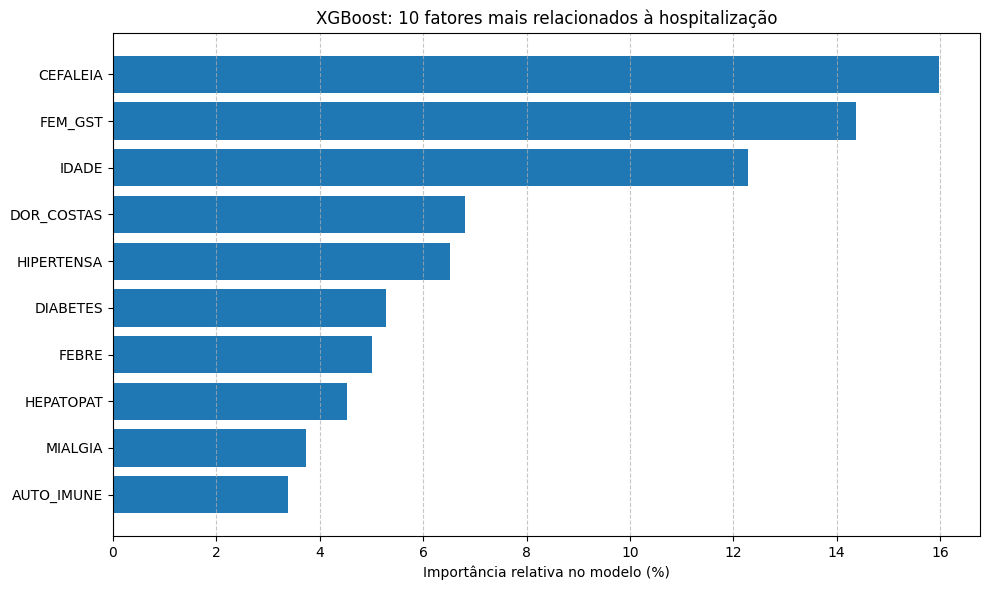

Importância das variáveis no XGBoost:
   Variável  Importância (%)
   CEFALEIA        15.974318
    FEM_GST        14.378142
      IDADE        12.289377
 DOR_COSTAS         6.814003
 HIPERTENSA         6.511790
   DIABETES         5.273403
      FEBRE         5.012671
  HEPATOPAT         4.535869
    MIALGIA         3.727808
 AUTO_IMUNE         3.394089
    ARTRITE         3.287415
  HEMATOLOG         2.683052
      RENAL         2.629005
FEM_NAO_GST         2.527236
  DOR_RETRO         2.458419
     NAUSEA         2.248766
  ARTRALGIA         2.240331
   EXANTEMA         1.601332
 ACIDO_PEPT         1.240610
 CONJUNTVIT         1.172367


In [17]:
importancias_xgb = melhor_xgb.feature_importances_
nomes_atributos = x_train.columns

df_importancia_xgb = pd.DataFrame({
    'Variável': nomes_atributos,
    'Importância (%)': importancias_xgb * 100
}).sort_values(by='Importância (%)', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_importancia_xgb['Variável'].head(10)[::-1], df_importancia_xgb['Importância (%)'].head(10)[::-1])
plt.xlabel('Importância relativa no modelo (%)')
plt.title('XGBoost: 10 fatores mais relacionados à hospitalização')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Importância das variáveis no XGBoost:")
print(df_importancia_xgb.to_string(index=False))

##### 5.7 Comparação entre classificadores<h5>

Para comparar os modelos, será utilizado a Curva ROC. A área sob a curva será usada para representar a capacidade geral de cada modelo de separar pacientes hospitalizados e não hospitalizados.

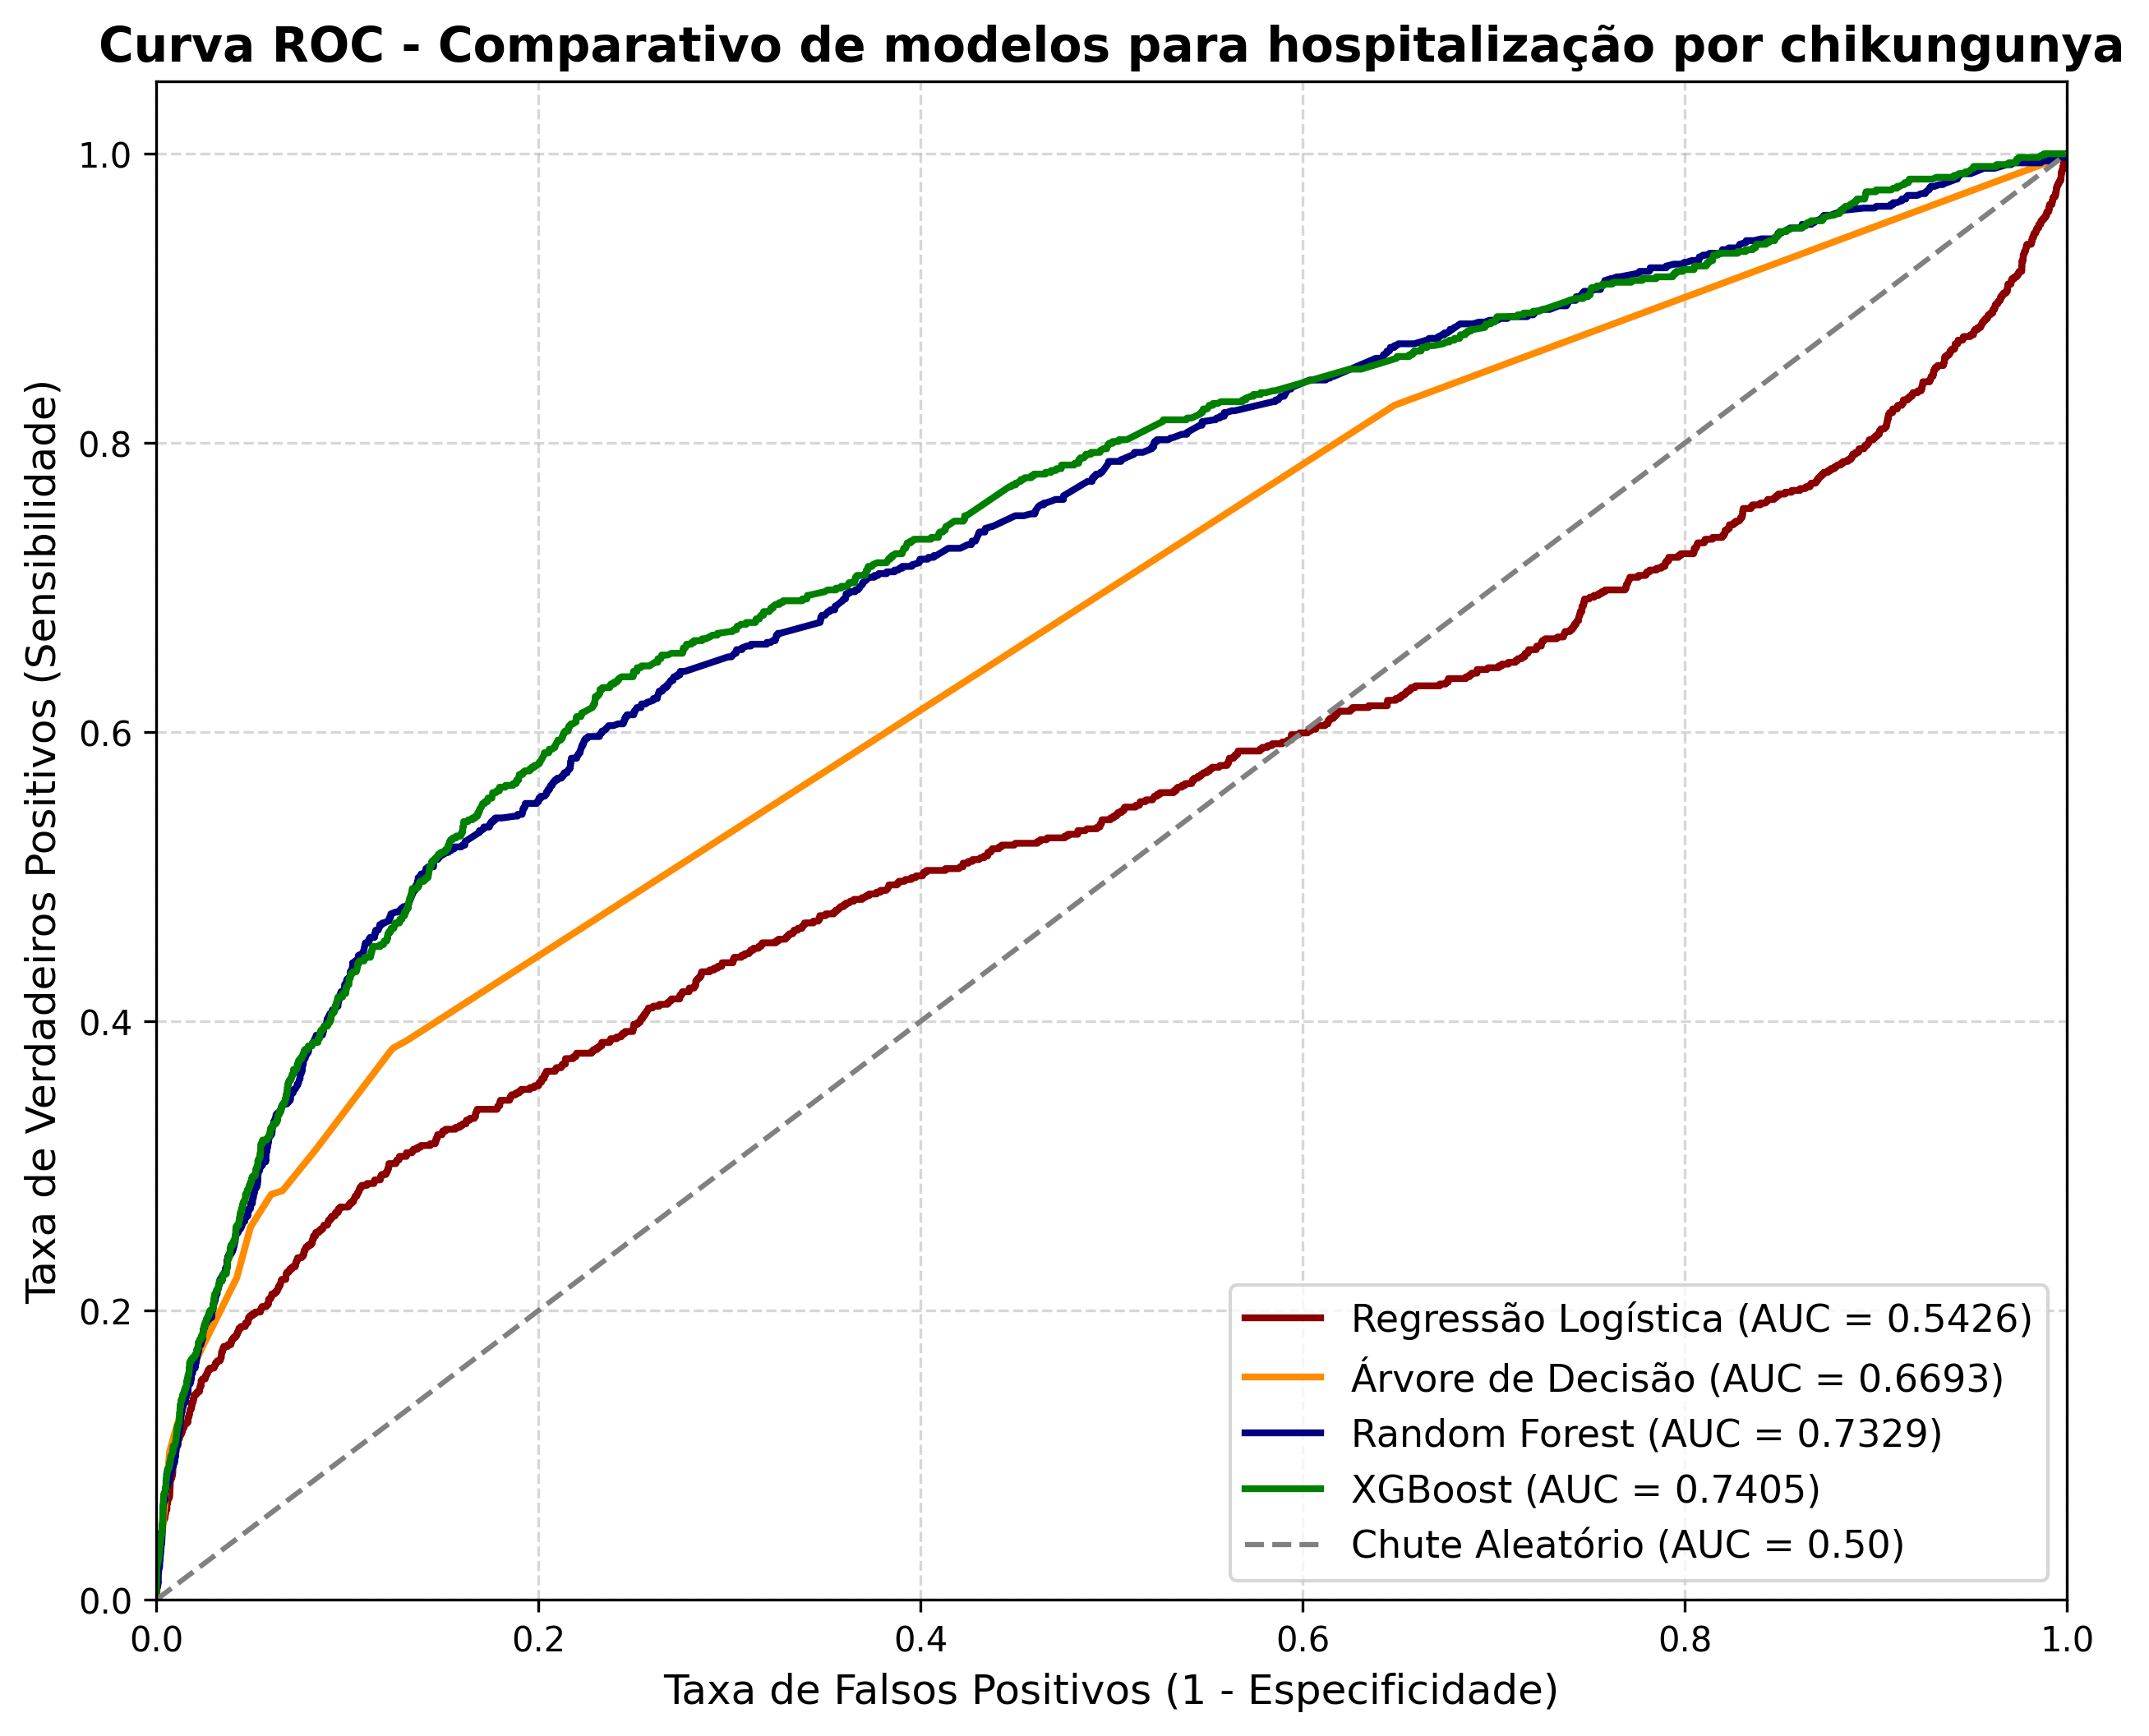

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Configurar a figura do gráfico
plt.figure(figsize=(10, 8), dpi=300)

# Dicionário com os melhores modelos já treinados
modelos = {
    'Regressão Logística': melhor_modelo,
    'Árvore de Decisão': melhor_dt,
    'Random Forest': melhor_rf,
    'XGBoost': melhor_xgb
}
# Cores para diferenciar os modelos no gráfico
cores = {
    'Regressão Logística': 'darkred',
    'Árvore de Decisão': 'darkorange',
    'Random Forest': 'navy',
    'XGBoost': 'green'
}

# Loop para calcular e plotar a curva de cada modelo
for nome, modelo in modelos.items():
    # Pegar a probabilidade do paciente ser da classe 1
    if hasattr(modelo, "predict_proba"):
        probs = modelo.predict_proba(x_test)[:, 1]
    else:
        # Caso algum modelo use decision_function, como SVM (não é o caso agora, mas o código já fica preparado)
        probs = modelo.decision_function(x_test)
        
    # Calcular as taxas de Falsos Positivos (fpr) e Verdadeiros Positivos (tpr)
    fpr, tpr, _ = roc_curve(y_test, probs)
    
    # Calcular a Área Abaixo da Curva (AUC)
    auc = roc_auc_score(y_test, probs)
    
    # Plotar a linha do modelo
    plt.plot(fpr, tpr, color=cores[nome], lw=2, label=f'{nome} (AUC = {auc:.4f})')

# Plotar a linha de referência (chute aleatório - diagonal)
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Chute Aleatório (AUC = 0.50)')

# Ajustes estéticos
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
plt.title('Curva ROC - Comparativo de modelos para hospitalização por chikungunya', fontsize=14, weight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Salvar a imagem em alta definição
plt.savefig('figuras/curva_roc_modelos_chikungunya.png', bbox_inches='tight', dpi=300)
plt.show()

## 6. Discussão dos resultados de Machine Learning

Ao final dos quatro experimentos, foram comparadas a **precisão** e a **sensibilidade** dos melhores ajustes de cada modelo.

| Modelo | Precisão | Sensibilidade |
| :--- | :---: | :---: |
| Regressão logística | 5,73% | 75,34% |
| Árvore de decisão | 4,90% | 82,60% |
| Floresta aleatória | 6,22% | 75,09% |
| XGBoost | 4,62% | 90,99% |

Os resultados mostram uma relação clara entre sensibilidade e precisão. O **XGBoost** apresentou a maior sensibilidade, identificando aproximadamente 91% dos pacientes hospitalizados. Entretanto, também apresentou a menor precisão entre os quatro modelos. Isso significa que o modelo conseguiu identificar a maior parte dos casos positivos, mas também classificou muitos pacientes não hospitalizados como pertencentes à classe positiva.

A **árvore de decisão** apresentou a segunda maior sensibilidade, com 82,60%, e precisão de 4,90%. O modelo conseguiu identificar uma parcela elevada dos pacientes hospitalizados, porém também apresentou uma quantidade considerável de falsos positivos.

A **floresta aleatória** apresentou a maior precisão, com 6,22%, e sensibilidade de 75,09%. Isso indica que o modelo foi um pouco mais seletivo ao classificar pacientes como hospitalizados, embora tenha deixado de identificar uma proporção maior de casos positivos quando comparado à árvore de decisão e ao XGBoost.

A **regressão logística** apresentou precisão de 5,73% e sensibilidade de 75,34%, alcançando resultados próximos aos da floresta aleatória. Apesar de ser um modelo mais simples, seu desempenho mostra que relações lineares entre as variáveis utilizadas conseguem capturar parte das características associadas à hospitalização.

De forma geral, todos os modelos apresentaram **sensibilidade consideravelmente superior à precisão**. Esse comportamento está relacionado principalmente ao desbalanceamento entre as classes e à utilização de pesos durante o treinamento. Ao atribuir maior importância aos pacientes hospitalizados, os modelos passaram a identificar uma parcela maior da classe positiva, mas também aumentaram a quantidade de falsos positivos.

A escolha do modelo mais adequado depende do objetivo da aplicação. Caso a prioridade seja reduzir a quantidade de pacientes hospitalizados não identificados, o XGBoost apresenta o melhor resultado de sensibilidade. Por outro lado, caso também seja importante reduzir a quantidade de falsos positivos, a floresta aleatória apresentou a melhor precisão entre os modelos avaliados.

Entretanto, precisão e sensibilidade não devem ser analisadas isoladamente. As matrizes de confusão, a acurácia, o F1-score e a área sob a Curva ROC também devem ser consideradas para uma avaliação mais completa do desempenho dos classificadores.

## 7. Síntese parcial dos modelos de Machine Learning

Os experimentos demonstraram que os quatro algoritmos conseguiram identificar uma parcela relevante dos pacientes hospitalizados, porém apresentaram baixa precisão para a classe positiva.

O XGBoost obteve a maior sensibilidade, enquanto a floresta aleatória apresentou a maior precisão. A regressão logística e a floresta aleatória apresentaram valores semelhantes de sensibilidade, apesar de possuírem níveis de complexidade diferentes.

Os resultados também evidenciam o impacto do desbalanceamento da variável-alvo. A utilização de pesos aumentou a capacidade dos modelos de detectar pacientes hospitalizados, mas também elevou a quantidade de pacientes não hospitalizados classificados incorretamente como positivos.

Portanto, não é possível determinar o melhor modelo considerando apenas uma única métrica. A escolha deve levar em conta o equilíbrio entre precisão, sensibilidade, F1-score, acurácia, matriz de confusão e área sob a Curva ROC.
